##Visualize GELECTRA emotion results (titles)

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### Load data

In [4]:
path="/Users/gretawette/Documents/Thesis/3a_Sentiment_Analysis/outputs/emotion_mainstream_results.csv"
df = pd.read_csv(path, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

In [5]:
df

,hit_id,row_id,source,Title,hit_text,context_idx,count_hits,count_unique_entities,context_window,model,...,raw_response_json,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope,emotion_dominant
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Politico,1,1,1,"Er hat es geschafft, seine Leute überall zu pl...",gpt-5-mini,...,"{""id"": ""resp_0e3ba66f85f590500069c463579898819...",0.931214,0.016498,0.004151,0.034111,0.002289,0.002552,0.005381,0.003804,anger
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Bild-Zeitung,1,1,1,Viele haben Reitschuster aus der Corona-Zeit j...,gpt-5-mini,...,"{""id"": ""resp_05d159969059d7ad0069c4635784cc819...",0.969122,0.002728,0.016191,0.010701,0.000280,0.000350,0.000411,0.000216,anger
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,1,1,1,Der Spiegel macht mal wieder Berichterstattung...,gpt-5-mini,...,"{""id"": ""resp_084a85555116e7270069c4635799bc819...",0.990522,0.001710,0.002913,0.004465,0.000110,0.000085,0.000112,0.000083,anger
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,2,1,1,Das NABU ist das vielleicht wichtigste Instrum...,gpt-5-mini,...,"{""id"": ""resp_067c239f074dd8230069c46357985c819...",0.600773,0.028491,0.008349,0.214184,0.019308,0.018475,0.083717,0.026703,anger
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,3,4,1,"Ich denke, die Antwort liegt auf der Hand. Mär...",gpt-5-mini,...,"{""id"": ""resp_0f30c6857a242fb20069c463578cd0819...",0.812990,0.023840,0.010760,0.097991,0.016858,0.005749,0.023543,0.008268,anger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11968,d5264d5629b3ae25,20436,Tagesschau,Bis zu 100 Sternschnuppen pro Stunde sind möglich,SWR,1,1,1,Rechtzeitig zum neuen Jahr zeigt sich der Ster...,gpt-5-mini,...,"{""id"": ""resp_09c97914638424680069c477b05720819...",0.204285,0.017436,0.002929,0.043715,0.140698,0.053735,0.467605,0.069597,pride
11969,a7bfcc1d5a5e0499,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",SWR,1,1,1,Und so hoch wie in diesem Jahr wird er wohl la...,gpt-5-mini,...,"{""id"": ""resp_05319e2d6eeb0e5b0069c477afd674819...",0.412528,0.055752,0.006826,0.138866,0.149546,0.023358,0.166882,0.046242,anger
11970,a3d2ff36023a08a5,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",SWR,2,2,1,Dezember 2026. SWR Kultur | SWR Impuls | 04.12...,gpt-5-mini,...,"{""id"": ""resp_0f4d24f64964ecf50069c477afe3cc819...",0.388046,0.054536,0.003009,0.027857,0.089540,0.066113,0.037865,0.333035,anger
11971,0049441f9d007ab9,20439,Tagesschau,Projekt zur Tierbeobachtung startet wieder,Deutschlandfunk,1,1,1,"Es war ein paar Mal schon so, dass es wirklich...",gpt-5-mini,...,"{""id"": ""resp_0f54fe164d0d1c940069c477b0ba44819...",0.931097,0.007829,0.002429,0.008909,0.010785,0.005962,0.017431,0.015557,anger


In [6]:
OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column found. Columns: {list(df.columns)}")

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

for c in EMOTION_COLS:
    if c not in df.columns:
        raise KeyError(f"Missing {c}; got {list(df.columns)}")


print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()

Rows: 11,973
Outlets (source): 7


,source,emotion_anger,emotion_fear,emotion_disgust
0,Antispiegel,0.931214,0.016498,0.004151
1,Antispiegel,0.969122,0.002728,0.016191
2,Antispiegel,0.990522,0.001710,0.002913
3,Antispiegel,0.600773,0.028491,0.008349
4,Antispiegel,0.812990,0.023840,0.010760


In [7]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [8]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,11973.0,0.6830,0.2715,0.0005,0.5032,0.7615,0.9150,0.9950
fear,11973.0,0.0511,0.0700,0.0002,0.0136,0.0292,0.0582,0.7385
disgust,11973.0,0.0070,0.0175,0.0001,0.0022,0.0037,0.0064,0.4330
sadness,11973.0,0.0834,0.1273,0.0002,0.0155,0.0384,0.0902,0.8914
joy,11973.0,0.0329,0.0818,0.0001,0.0016,0.0065,0.0247,0.9331
enthusiasm,11973.0,0.0196,0.0308,0.0001,0.0018,0.0075,0.0248,0.4769
pride,11973.0,0.0522,0.0997,0.0000,0.0024,0.0125,0.0507,0.8165
hope,11973.0,0.0707,0.1391,0.0001,0.0035,0.0177,0.0633,0.9169


In [10]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tagesschau,4370,36.50
6,Tichys_Einblick,2282,19.06
3,Nius,2026,16.92
4,RT_de,1862,15.55
0,Antispiegel,540,4.51
1,Compact,512,4.28
2,Deutschlandkurier,381,3.18


In [11]:
print("Dominant emotion (full corpus):")
print(df["emotion_dominant"].value_counts(normalize=True).round(4) * 100)

print("\nDominant emotion by outlet (share within each outlet, %):")
dominant_share = pd.crosstab(
    df[OUTLET_COL], df["emotion_dominant"], normalize="index"
).round(4) * 100
display(dominant_share)

Dominant emotion (full corpus):
emotion_dominant
anger         84.60
hope           5.39
sadness        4.22
pride          3.55
joy            1.49
fear           0.73
disgust        0.03
enthusiasm     0.01
Name: proportion, dtype: float64

Dominant emotion by outlet (share within each outlet, %):


emotion_dominant,anger,disgust,enthusiasm,fear,hope,joy,pride,sadness
source,,,,,,,,
Antispiegel,95.00,0.00,0.0,0.19,1.30,0.00,2.22,1.30
Compact,84.77,0.00,0.2,0.78,2.54,0.98,5.86,4.88
Deutschlandkurier,91.08,0.00,0.0,0.26,4.72,0.52,1.84,1.57
Nius,88.99,0.10,0.0,0.54,1.63,1.18,2.91,4.64
RT_de,89.42,0.00,0.0,0.86,3.44,0.27,1.99,4.03
Tagesschau,74.10,0.02,0.0,1.10,11.10,2.97,4.78,5.93
Tichys_Einblick,93.30,0.00,0.0,0.26,1.10,0.53,3.11,1.71


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

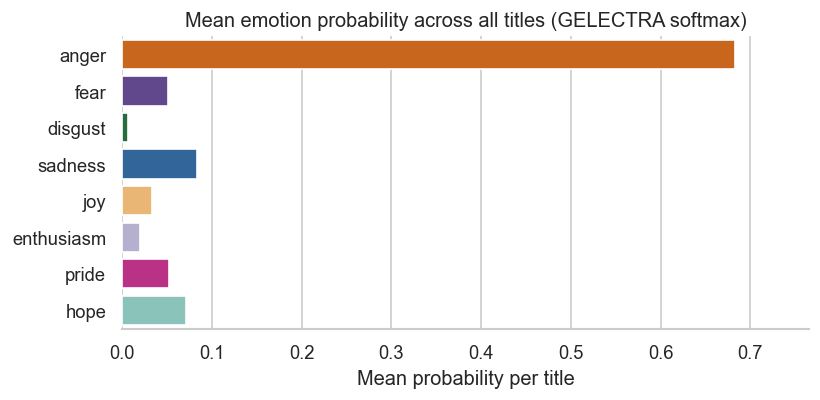

In [12]:
emotion_means = df[EMOTION_COLS].mean()
plot_df = pd.DataFrame({"emotion": EMOTION_SHORT, "mean_prob": emotion_means.values})

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=plot_df,
    x="mean_prob",
    y="emotion",
    hue="emotion",
    dodge=False,
    palette=[emotion_colors[e] for e in plot_df["emotion"]],
    legend=False,
)
plt.title("Mean emotion probability across all titles (GELECTRA softmax)")
plt.xlabel("Mean probability per title")
plt.ylabel("")
plt.xlim(0, plot_df["mean_prob"].max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### By outlet: heatmap of mean probabilities

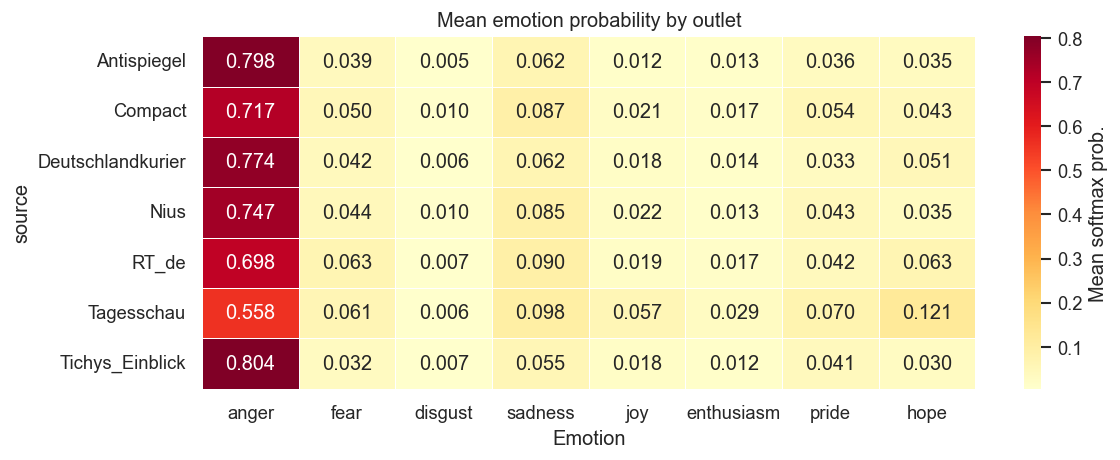

In [13]:
mean_by_outlet = df.groupby(OUTLET_COL, observed=True)[EMOTION_COLS].mean()
mean_by_outlet.columns = EMOTION_SHORT
mean_by_outlet = mean_by_outlet.sort_index()

plt.figure(figsize=(10, max(4, 0.35 * len(mean_by_outlet))))
sns.heatmap(
    mean_by_outlet,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean softmax prob."},
)
plt.title("Mean emotion probability by outlet")
plt.ylabel(OUTLET_COL)
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

### Grouped bars: mean probability per emotion, faceted by outlet

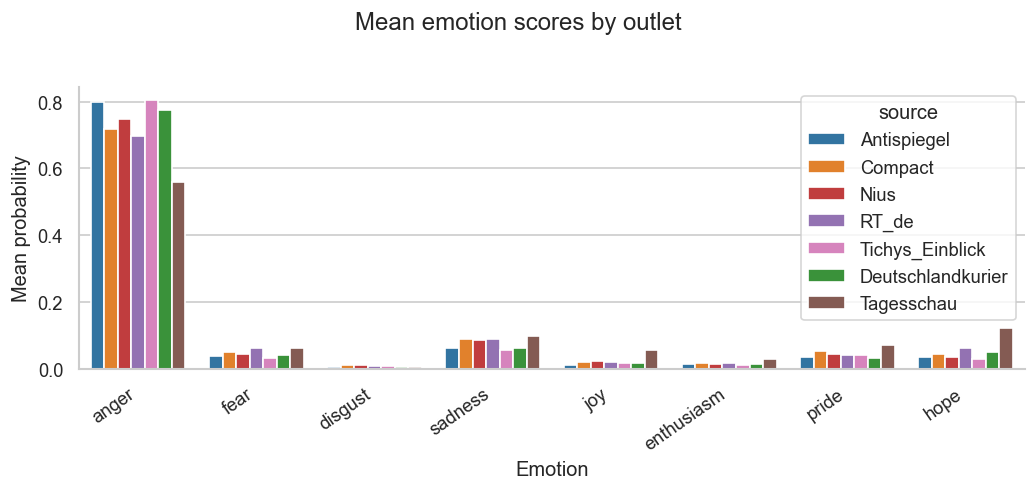

In [14]:
melt_outlet = df.melt(
    id_vars=[OUTLET_COL],
    value_vars=EMOTION_COLS,
    var_name="emotion_col",
    value_name="prob",
)
melt_outlet["emotion"] = melt_outlet["emotion_col"].str.replace("emotion_", "")

g = sns.catplot(
    data=melt_outlet,
    kind="bar",
    x="emotion",
    y="prob",
    hue=OUTLET_COL,
    palette=outlet_colors,
    height=4,
    aspect=2.2,
    legend_out=False,
    errorbar=None,
    estimator="mean",
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Emotion", "Mean probability")
g.figure.suptitle("Mean emotion scores by outlet", y=1.02)
plt.tight_layout()
plt.show()

### Dominant-emotion shares by outlet (%)

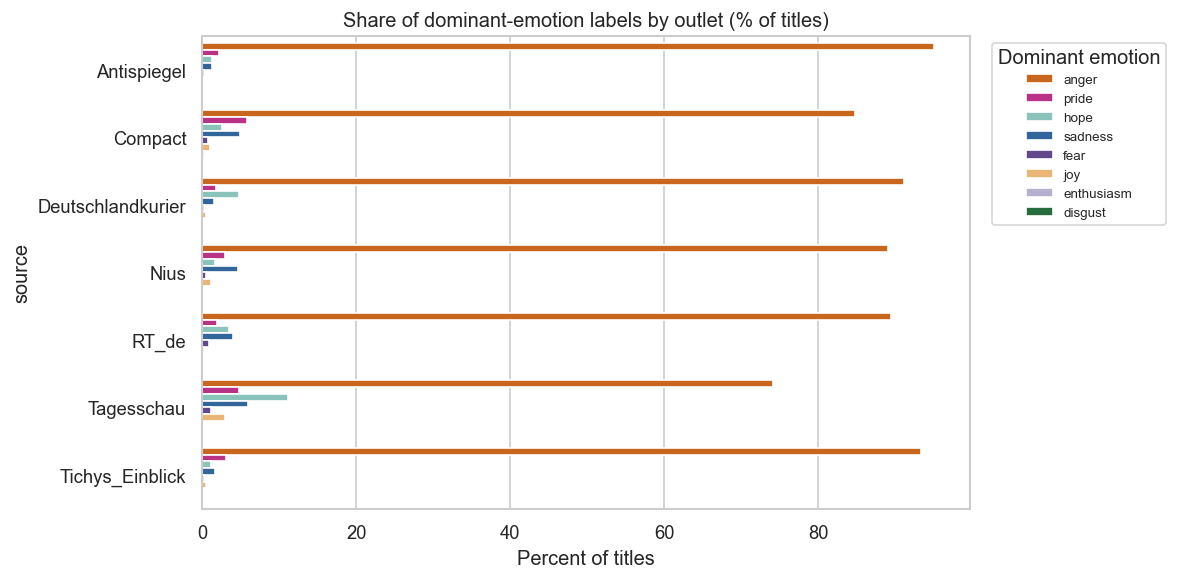

In [15]:
dom_share = (
    df.groupby(OUTLET_COL, observed=True)["emotion_dominant"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dom_share,
    x="pct",
    y=OUTLET_COL,
    hue="emotion_dominant",
    palette=emotion_colors,
    dodge=True,
)
plt.title("Share of dominant-emotion labels by outlet (% of titles)")
plt.xlabel("Percent of titles")
plt.legend(title="Dominant emotion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Emotion vs. Framing category & hits

In [26]:
df= df[df['evidence'].notna()]

In [47]:
df['source'].value_counts()

source
Tichys_Einblick      1254
Nius                  857
RT_de                 398
Antispiegel           309
Compact               182
Deutschlandkurier     138
Tagesschau             54
Name: count, dtype: int64

In [27]:


# Filter emotion probability columns (assume columns starting with 'emotion_' and not 'emotion_dominant')
emotion_prob_cols = [col for col in df.columns if col.startswith("emotion_") and col not in ["emotion_dominant"]]

# Compute mean emotion probabilities per framing category
framing_emotion_means = (
    df.groupby("category")[emotion_prob_cols]
    .mean()
    .reset_index()
    .rename_axis(None, axis=1)
)

# Sort framing categories by count, if desired (optional)
# framing_order = df["framing"].value_counts().index
# framing_emotion_means["framing"] = pd.Categorical(framing_emotion_means["framing"], categories=framing_order, ordered=True)
# framing_emotion_means = framing_emotion_means.sort_values("framing")

display(framing_emotion_means)


,category,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope
0,DISINFORMATION/FALSCHDARSTELLUNG,0.880955,0.019669,0.006847,0.047810,0.008109,0.006050,0.017776,0.012783
1,POSITIONS-/PARTEILICHKEITS-BIAS,0.836606,0.028915,0.007605,0.052441,0.011189,0.010528,0.031516,0.021200
2,VERSAGEN/INKOMPETENZ,0.813198,0.031811,0.009406,0.067173,0.014864,0.009185,0.031781,0.022581
3,VERZERRUNG/MANIPULATION,0.848892,0.028418,0.008806,0.058528,0.011147,0.007273,0.021962,0.014975


Mean anger/fear per framing category (Alternative media):


,category,emotion_anger,emotion_fear
0,DISINFORMATION/FALSCHDARSTELLUNG,0.882270,0.019425
1,POSITIONS-/PARTEILICHKEITS-BIAS,0.838272,0.028446
2,VERSAGEN/INKOMPETENZ,0.817091,0.031834
3,VERZERRUNG/MANIPULATION,0.849043,0.028426


/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_54115/2202794748.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


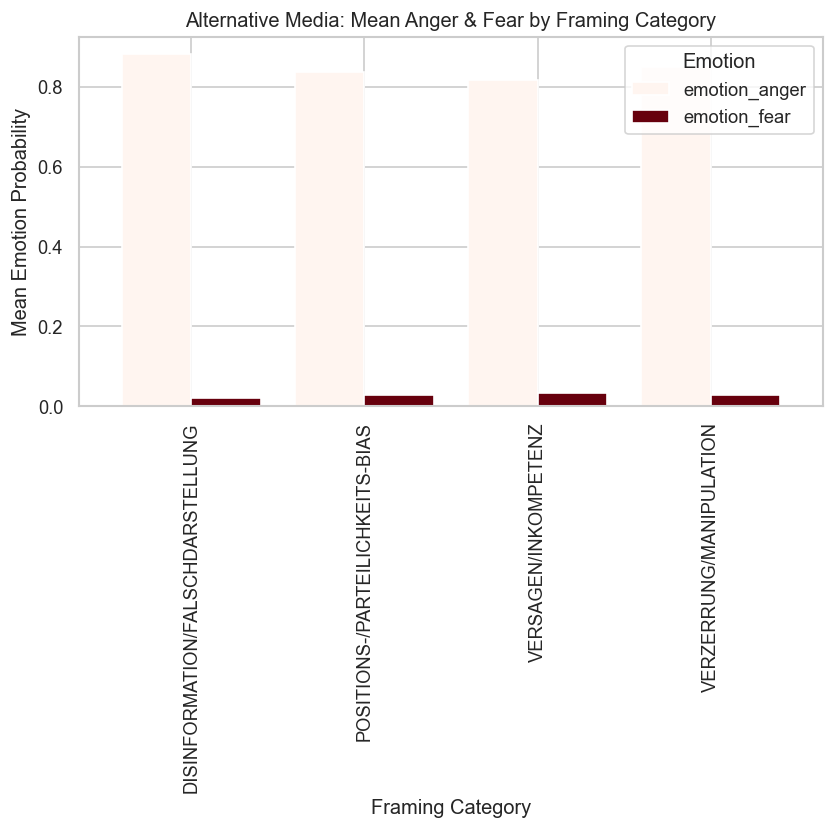

Mean anger/fear per framing category (Tagesschau):


,category,emotion_anger,emotion_fear
0,DISINFORMATION/FALSCHDARSTELLUNG,0.783091,0.037843
1,POSITIONS-/PARTEILICHKEITS-BIAS,0.762541,0.049771
2,VERSAGEN/INKOMPETENZ,0.566410,0.030368
3,VERZERRUNG/MANIPULATION,0.836475,0.027773


/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_54115/2202794748.py:51: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


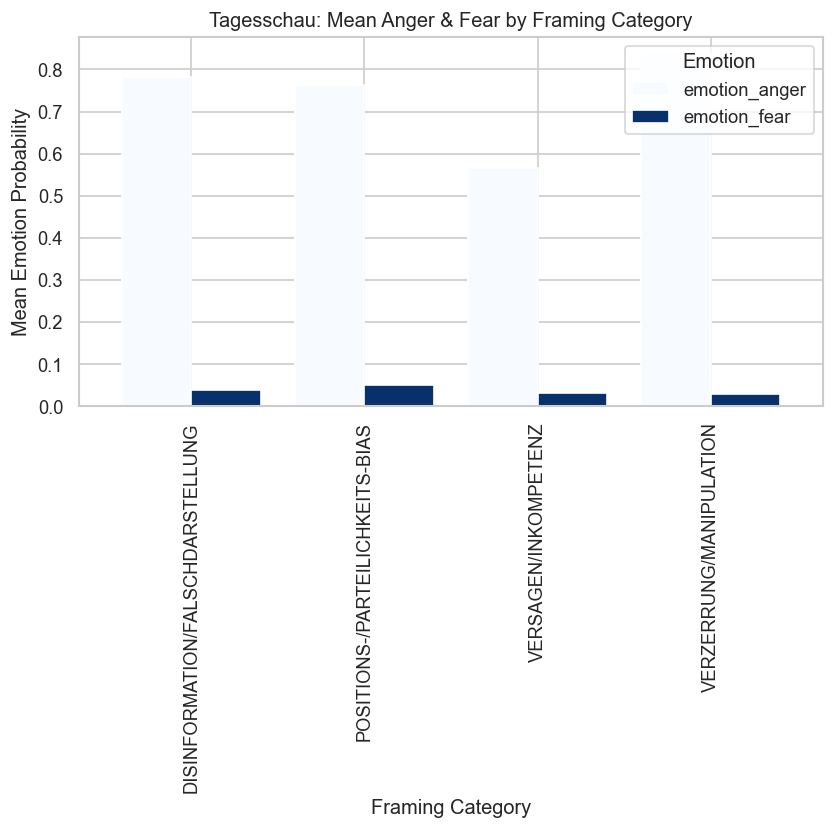

In [48]:
import matplotlib.pyplot as plt

# Only focus on 'emotion_anger' and 'emotion_fear'
emotions_of_interest = ["emotion_anger", "emotion_fear"]

# Define sources
alt_sources = ['Antispiegel', 'Compact', 'Deutschlandkurier', 'Nius', 'RT_de', 'Tichys_Einblick']
mainstream_source = 'Tagesschau'

# 1. Table for alternative media sources (grouped by category, mean of anger and fear)
alt_df = df[df['source'].isin(alt_sources)]
alt_framing_emotion_means = (
    alt_df.groupby("category")[emotions_of_interest]
    .mean()
    .reset_index()
)

print("Mean anger/fear per framing category (Alternative media):")
display(alt_framing_emotion_means)

# Optional: Plot for alt sources
ax1 = alt_framing_emotion_means.set_index('category')[emotions_of_interest].plot(
    kind="bar", figsize=(8, 4), colormap="Reds", width=0.8
)
plt.title("Alternative Media: Mean Anger & Fear by Framing Category")
plt.xlabel("Framing Category")
plt.ylabel("Mean Emotion Probability")
plt.legend(title="Emotion")
plt.tight_layout()
plt.show()

# 2. Table for Tagesschau (grouped by category, mean of anger and fear)
tagesschau_df = df[df['source'] == mainstream_source]
tagesschau_framing_emotion_means = (
    tagesschau_df.groupby("category")[emotions_of_interest]
    .mean()
    .reset_index()
)

print("Mean anger/fear per framing category (Tagesschau):")
display(tagesschau_framing_emotion_means)

# Optional: Plot for Tagesschau
ax2 = tagesschau_framing_emotion_means.set_index('category')[emotions_of_interest].plot(
    kind="bar", figsize=(8, 4), colormap="Blues", width=0.8
)
plt.title("Tagesschau: Mean Anger & Fear by Framing Category")
plt.xlabel("Framing Category")
plt.ylabel("Mean Emotion Probability")
plt.legend(title="Emotion")
plt.tight_layout()
plt.show()

In [30]:
df['category'].value_counts()

category
POSITIONS-/PARTEILICHKEITS-BIAS     1409
VERZERRUNG/MANIPULATION             1084
DISINFORMATION/FALSCHDARSTELLUNG     377
VERSAGEN/INKOMPETENZ                 322
Name: count, dtype: int64

,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope
hit_text,,,,,,,,
Markus Lanz,0.887801,0.017230,0.007824,0.037014,0.006959,0.008214,0.017987,0.016972
taz,0.887249,0.019652,0.006118,0.034920,0.007870,0.007582,0.020973,0.015637
Markus Lanz | ZDF,0.871838,0.024329,0.009898,0.061385,0.004886,0.005683,0.012774,0.009207
Correctiv,0.869209,0.023450,0.004277,0.037213,0.007887,0.009581,0.022532,0.025852
Stern,0.868477,0.020664,0.012508,0.058760,0.005626,0.005393,0.019250,0.009322
FAZ,0.867280,0.026897,0.009727,0.039691,0.016105,0.006279,0.021465,0.012556
Deutschlandfunk,0.864101,0.024437,0.005808,0.061330,0.008984,0.005999,0.017152,0.012190
The European,0.844177,0.019565,0.006149,0.058791,0.009189,0.009534,0.038710,0.013884
Tagesschau,0.842513,0.033539,0.011965,0.062093,0.012869,0.006675,0.016700,0.013647


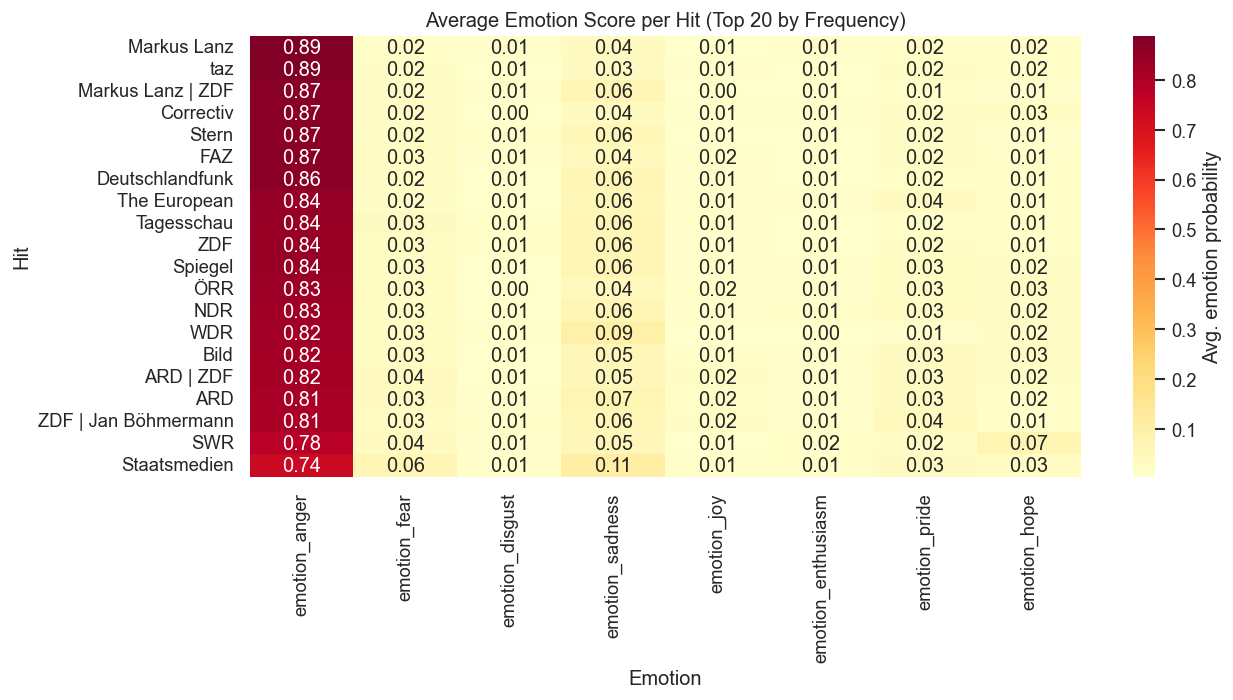

In [31]:
# Show average emotion score for the top 20 most frequent "hits" (words) in the 'hits' column

# First, identify the top 20 most common hits (words)
top_hits = df['hit_text'].value_counts().head(20).index

# Filter dataframe to only rows where 'hits' is one of the top 20
df_top_hits = df[df['hit_text'].isin(top_hits)]

# Select emotion columns (probabilities, not 'emotion_dominant')
emotion_cols = [col for col in df.columns if col.startswith("emotion_") and col not in ["emotion_dominant"]]

# Compute average emotion scores for each top hit (word)
avg_emotions_hits = (
    df_top_hits.groupby('hit_text')[emotion_cols]
    .mean()
    .sort_values(by="emotion_anger", ascending=False)  # sort by one emotion for visibility, optional
)

display(avg_emotions_hits)

# Optional: Plot as heatmap for more visibility
plt.figure(figsize=(11, 6))
sns.heatmap(
    avg_emotions_hits,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Avg. emotion probability"},
)
plt.title("Average Emotion Score per Hit (Top 20 by Frequency)")
plt.ylabel("Hit")
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

,row_id,source,hit_text,emotion_max_type,emotion_max_score,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope
7539,13784,Deutschlandkurier,Staatsfunk,anger,0.995024,0.995024,0.001511,0.001274,0.001336,0.000236,0.000166,0.000191,0.000263
1247,2411,Nius,ARD | ZDF,anger,0.994891,0.994891,0.001193,0.002073,0.001452,0.000093,0.000106,0.000097,0.000094
1234,2389,Nius,taz | ARD | ZDF,anger,0.994886,0.994886,0.001190,0.002025,0.001059,0.000157,0.000244,0.000209,0.000231
10077,17328,Tagesschau,ZDF,anger,0.994719,0.994719,0.001529,0.001205,0.001665,0.000171,0.000206,0.000232,0.000273
2487,4307,Nius,Frankfurter Allgemeine Zeitung | FAZ,anger,0.994620,0.994620,0.001392,0.001145,0.001192,0.000420,0.000308,0.000402,0.000522
7118,12506,Tichys_Einblick,Tagesschau,anger,0.994415,0.994415,0.001412,0.001300,0.002076,0.000143,0.000195,0.000231,0.000229
2402,4131,Nius,rbb,anger,0.994353,0.994353,0.001593,0.001209,0.002049,0.000160,0.000180,0.000228,0.000227
5277,10298,Tichys_Einblick,ARD | ZDF,anger,0.994212,0.994212,0.001427,0.001731,0.001794,0.000185,0.000197,0.000237,0.000218
5875,11050,Tichys_Einblick,Staatsfunk,anger,0.994010,0.994010,0.002562,0.001593,0.001493,0.000080,0.000090,0.000067,0.000105
1428,2752,Nius,ZDF,anger,0.993941,0.993941,0.001681,0.001637,0.002339,0.000084,0.000105,0.000094,0.000119


/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_54115/1755200945.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


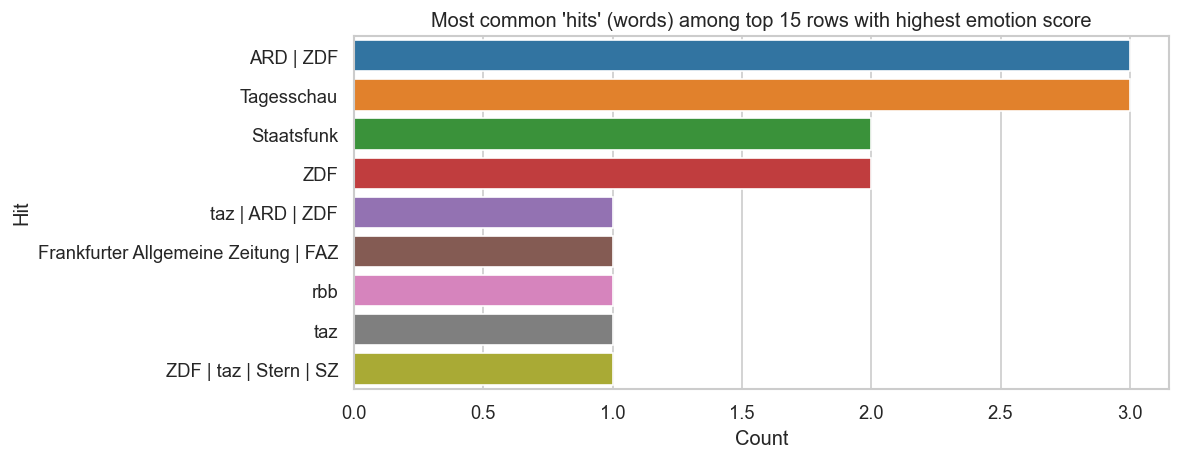

/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_54115/1755200945.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


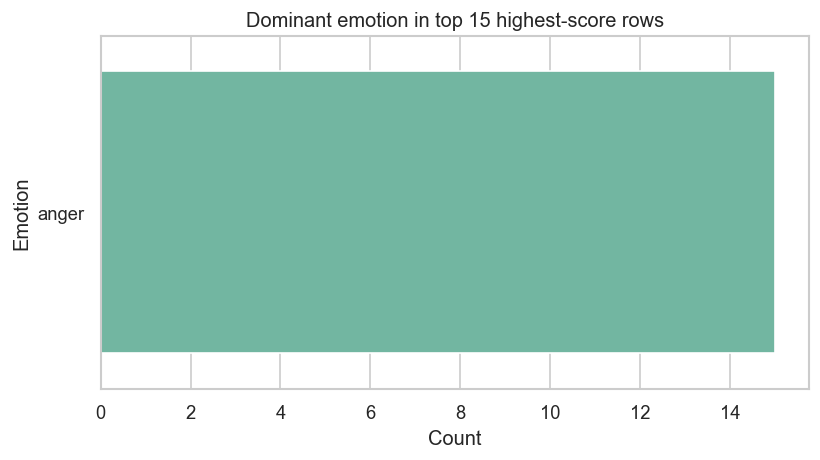

In [32]:

# Show rows with the highest *single* emotion score (across all emotion columns)

# Which columns are the emotions?
emotion_cols = [col for col in df.columns if col.startswith("emotion_") and col not in ["emotion_dominant"]]

# For each row, find the max softmax probability and which emotion it is
df["emotion_max_score"] = df[emotion_cols].max(axis=1)
df["emotion_max_type"] = df[emotion_cols].idxmax(axis=1).str.replace("emotion_", "")

# Show top N rows with the highest emotion score
top_n = 15
top_rows = df.sort_values("emotion_max_score", ascending=False).head(top_n)

display_cols = ["row_id", OUTLET_COL, "hit_text", "emotion_max_type", "emotion_max_score"] + emotion_cols
display(top_rows[display_cols])

# Plot what hits are present among these top-scoring emotion rows
plt.figure(figsize=(10, 4))
sns.countplot(
    data=top_rows,
    y="hit_text",
    order=top_rows["hit_text"].value_counts().index,
    palette="tab10"
)
plt.title(f"Most common 'hits' (words) among top {top_n} rows with highest emotion score")
plt.xlabel("Count")
plt.ylabel("Hit")
plt.tight_layout()
plt.show()

# Optionally, cross-tabulate which emotion type dominates among these top rows
plt.figure(figsize=(7, 4))
sns.countplot(
    data=top_rows,
    y="emotion_max_type",
    order=top_rows["emotion_max_type"].value_counts().index,
    palette="Set2"
)
plt.title(f"Dominant emotion in top {top_n} highest-score rows")
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()




In [33]:
def split_hit_text_to_segments(s):
    """Split pipe-separated hit strings into individual labels."""
    if not isinstance(s, str) or not str(s).strip():
        return []
    return [p.strip() for p in str(s).split("|") if str(p).strip()]


df_for_hits = (
    df.assign(hit_segment=df["hit_text"].map(split_hit_text_to_segments))
    .explode("hit_segment", ignore_index=True)
)
df_for_hits = df_for_hits.dropna(subset=["hit_segment"])

# Example: original vs exploded row count
print(f"Rows before split/explode: {len(df):,}")
print(f"Rows after split/explode (one row per segment): {len(df_for_hits):,}")

Rows before split/explode: 3,192
Rows after split/explode (one row per segment): 4,872


In [46]:
# Show average emotion score for the top 20 most frequent "hits" (words) in the 'hits' column

# First, identify the top 20 most common hits (words)
top_hits = df_for_hits['hit_text'].value_counts().head(20).index

# Filter dataframe to only rows where 'hits' is one of the top 20
df_top_hits = df_for_hits[df_for_hits['hit_text'].isin(top_hits)]

# Select emotion columns (probabilities, not 'emotion_dominant')
emotion_cols = [col for col in df_for_hits.columns if col.startswith("emotion_") and col not in ["emotion_dominant"]]

# Compute average emotion scores for each top hit (word)
avg_emotions_hits = (
    df_top_hits.groupby('hit_text')["emotion_anger"]
    .mean()
    .sort_values(by="emotion_anger", ascending=False)  # sort by one emotion for visibility, optional
)

display(avg_emotions_hits)

TypeError: Series.sort_values() got an unexpected keyword argument 'by'

,emotion_anger,emotion_fear,emotion_disgust,emotion_sadness,emotion_joy,emotion_enthusiasm,emotion_pride,emotion_hope
hit_text,,,,,,,,
Markus Lanz,0.887801,0.017230,0.007824,0.037014,0.006959,0.008214,0.017987,0.016972
taz,0.887249,0.019652,0.006118,0.034920,0.007870,0.007582,0.020973,0.015637
Markus Lanz | ZDF,0.871838,0.024329,0.009898,0.061385,0.004886,0.005683,0.012774,0.009207
Correctiv,0.869209,0.023450,0.004277,0.037213,0.007887,0.009581,0.022532,0.025852
Stern,0.868477,0.020664,0.012508,0.058760,0.005626,0.005393,0.019250,0.009322
FAZ,0.867280,0.026897,0.009727,0.039691,0.016105,0.006279,0.021465,0.012556
Deutschlandfunk,0.864101,0.024437,0.005808,0.061330,0.008984,0.005999,0.017152,0.012190
The European,0.844177,0.019565,0.006149,0.058791,0.009189,0.009534,0.038710,0.013884
Tagesschau,0.842513,0.033539,0.011965,0.062093,0.012869,0.006675,0.016700,0.013647


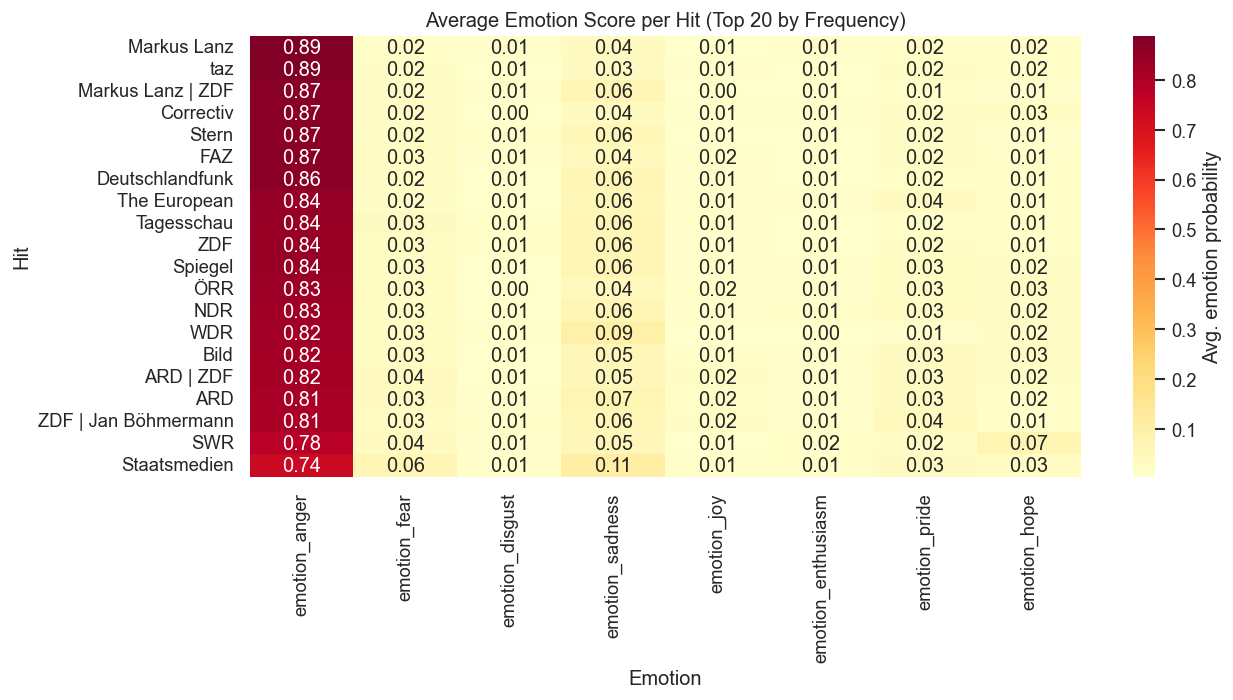

In [ ]:



# Optional: Plot as heatmap for more visibility
plt.figure(figsize=(11, 6))
sns.heatmap(
    avg_emotions_hits,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Avg. emotion probability"},
)
plt.title("Average Emotion Score per Hit (Top 20 by Frequency)")
plt.ylabel("Hit")
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

In [40]:
# Compute average emotion scores for each top hit (word)
avg_emotions_hits = (
    df_top_hits.groupby('hit_text')[emotion_cols]
    .mean()
    .sort_values(by="emotion_anger", ascending=False)  # sort by one emotion for visibility, optional
)



TypeError: dtype 'str' does not support operation 'mean'

In [36]:
df_for_hits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4872 entries, 0 to 4871
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hit_id                 4872 non-null   str    
 1   row_id                 4872 non-null   int64  
 2   source                 4872 non-null   str    
 3   Title                  4872 non-null   str    
 4   hit_text               4872 non-null   str    
 5   context_idx            4872 non-null   int64  
 6   count_hits             4872 non-null   int64  
 7   count_unique_entities  4872 non-null   int64  
 8   context_window         4872 non-null   str    
 9   model                  4872 non-null   str    
 10  response_id            4872 non-null   str    
 11  category               4872 non-null   str    
 12  evidence               4872 non-null   str    
 13  raw_response_json      4872 non-null   str    
 14  emotion_anger          4872 non-null   float64
 15  emotion_fear   

### Example: distribution of **anger** and **fear** by outlet (boxplot)

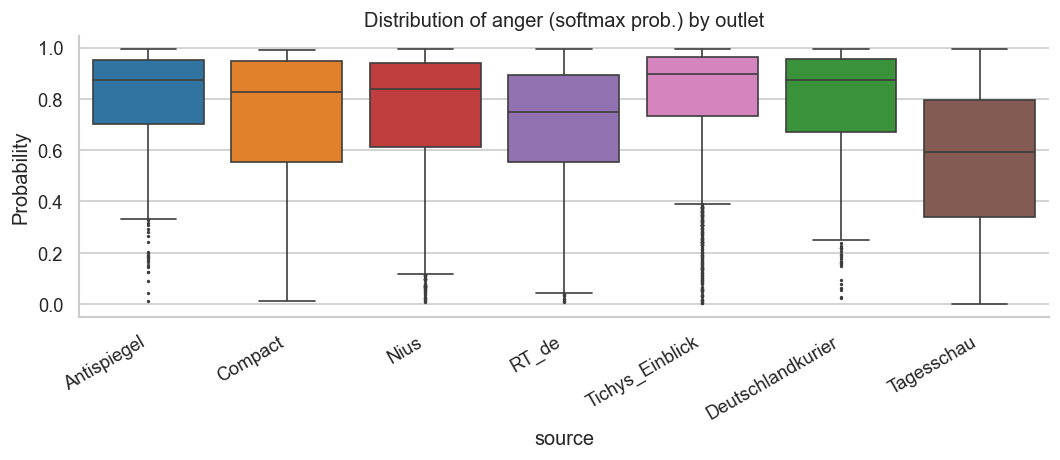

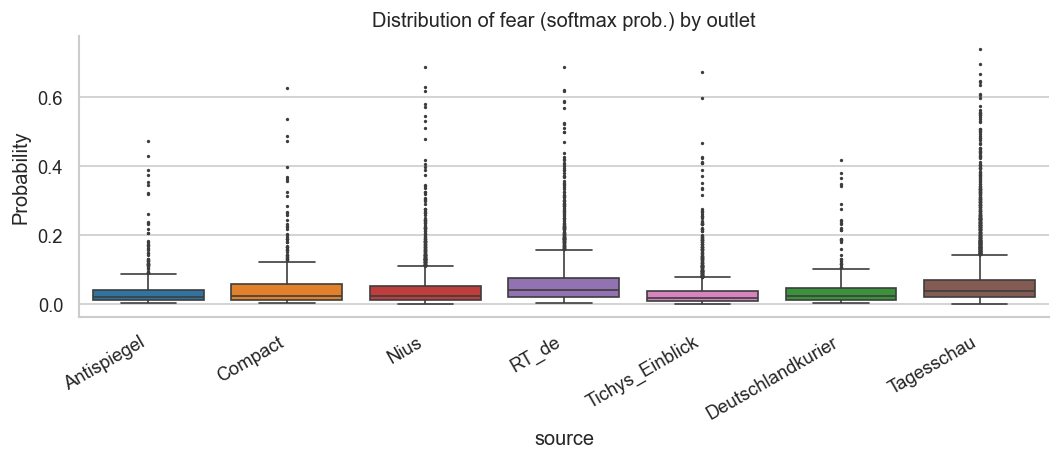

In [21]:
for emo, col in [("anger", "emotion_anger"), ("fear", "emotion_fear")]:
    plt.figure(figsize=(9, 4))
    sns.boxplot(
        data=df,
        x=OUTLET_COL,
        y=col,
        hue=OUTLET_COL,
        palette=outlet_colors,
        dodge=False,
        legend=False,
        fliersize=1,
    )
    plt.title(f"Distribution of {emo} (softmax prob.) by outlet")
    plt.xlabel(OUTLET_COL)
    plt.ylabel("Probability")
    plt.xticks(rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    plt.show()

/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_63186/2086565043.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


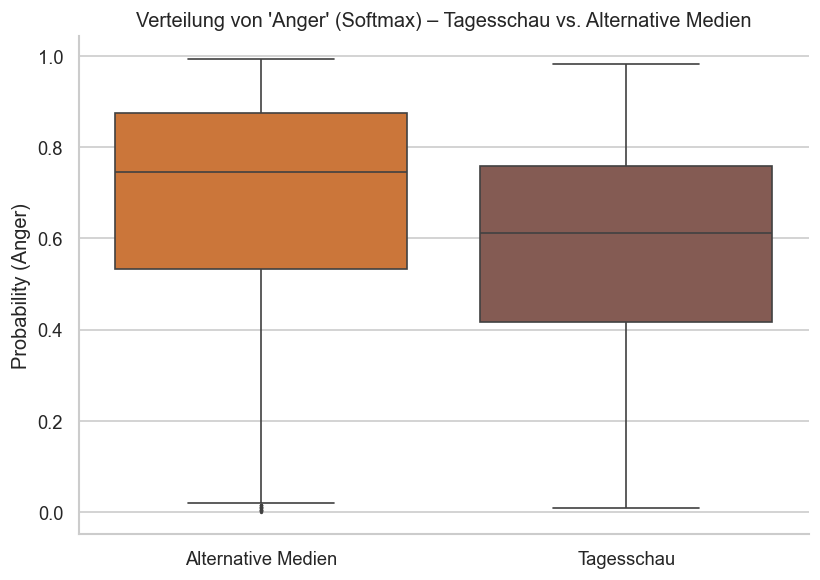

In [16]:
# Combine all alternative outlets vs Tagesschau for anger boxplot

# Define which are the alternative outlets
tagesschau_name = "Tagesschau"
alt_outlets = [o for o in df[OUTLET_COL].unique() if o != tagesschau_name]

# Create a new column for group
df["outlet_group"] = df[OUTLET_COL].apply(lambda x: "Tagesschau" if x == tagesschau_name else "Alternative Medien")

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="outlet_group",
    y="emotion_anger",
    palette={
        "Tagesschau": outlet_colors[tagesschau_name] if tagesschau_name in outlet_colors else "#193b5b",
        "Alternative Medien": "#e37222",
    },
    fliersize=1,
)
plt.title("Verteilung von 'Anger' (Softmax) – Tagesschau vs. Alternative Medien")
plt.xlabel("")
plt.ylabel("Probability (Anger)")
sns.despine()
plt.tight_layout()
plt.show()


In [17]:
is_anger_dom = (df["emotion_dominant"] == "anger").astype(int)
sub = df[df["outlet_group"].isin(["Tagesschau", "Alternative Medien"])].copy()

In [18]:
from scipy import stats

sub["anger_dom"] = sub["emotion_dominant"].eq("anger")
ct = pd.crosstab(sub["outlet_group"], sub["anger_dom"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print("Contingency table:\n", ct)
print("chi2 =", chi2, "p =", p)

# If counts are small:
odds_ratio, p_fisher = stats.fisher_exact(ct)  # 2x2 only
print("Fisher exact p =", p_fisher)

Contingency table:
 anger_dom           False  True 
outlet_group                    
Alternative Medien   1755  12357
Tagesschau           1169   5150
chi2 = 130.36082853090707 p = 3.4166648338880745e-30
Fisher exact p = 2.9349042864678343e-29


In [19]:
a = sub.loc[sub["outlet_group"] == "Tagesschau", "emotion_anger"]
b = sub.loc[sub["outlet_group"] == "Alternative Medien", "emotion_anger"]
stats.mannwhitneyu(a, b, alternative="two-sided")

MannwhitneyuResult(statistic=np.float64(31998500.0), pvalue=np.float64(5.722547030560032e-229))

### Export summary tables (optional)

Saved next to figures for use in the thesis.

In [ ]:
# summary_stats.to_csv(FIG_DIR / "../tables_emotion_summary_stats.csv")
# mean_by_outlet.to_csv(FIG_DIR / "../tables_mean_emotion_by_outlet.csv")
# outlet_summary.to_csv(FIG_DIR / "../tables_outlet_counts.csv", index=False)
# print("Wrote CSV tables to outputs/tables_*.csv")